<a href="https://colab.research.google.com/github/nlan082/bai_tap_AI/blob/main/2_5Dieuhoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 8.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [5]:
#
temperature=ctrl.Antecedent(np.arange(0,41,1),'temperature')
humidity=ctrl.Antecedent(np.arange(0,101,1),'humidity')
human=ctrl.Antecedent(np.arange(0,2.1,0.1),'human')
fanspeed=ctrl.Consequent(np.arange(0,2.1, 0.1),'fanspeed')
cooling=ctrl.Consequent(np.arange(0,2.1,0.1),'cooling')


In [13]:
temperature['c']=fuzz.trimf(temperature.universe,[0,0,15])
temperature['cl']=fuzz.trimf(temperature.universe,[10,15,20])
temperature['cm']=fuzz.trimf(temperature.universe,[20,25,30])
temperature['w']=fuzz.trimf(temperature.universe,[25,30,35])
temperature['h']=fuzz.trimf(temperature.universe,[30,40,40])
humidity['l']=fuzz.trimf(humidity.universe,[0,50, 50])
humidity['m']=fuzz.trimf(humidity.universe,[40,60,80])
humidity['h']=fuzz.trimf(humidity.universe,[60,100,100])
human['f']=fuzz.trimf(human.universe,[0,0,1])
human['m']=fuzz.trimf(human.universe,[0,1,2])
human['ma']=fuzz.trimf(human.universe,[1,2,2])
fanspeed['l']=fuzz.trimf(fanspeed.universe,[0,0,1])
fanspeed['m']=fuzz.trimf(fanspeed.universe,[0,1,2])
fanspeed['h']=fuzz.trimf(fanspeed.universe,[1,2,2])
cooling['l']=fuzz.trimf(cooling.universe,[0,0,1])
cooling['m']=fuzz.trimf(cooling.universe,[0,1,2])
cooling['h']=fuzz.trimf(cooling.universe,[1,2,2])


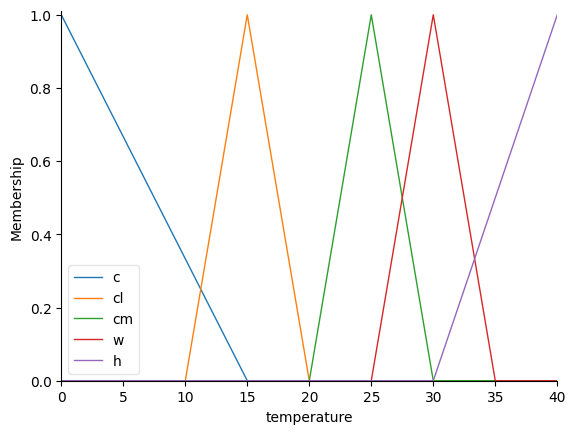

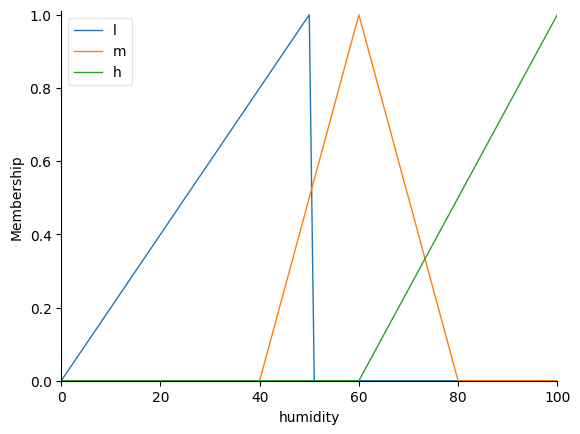

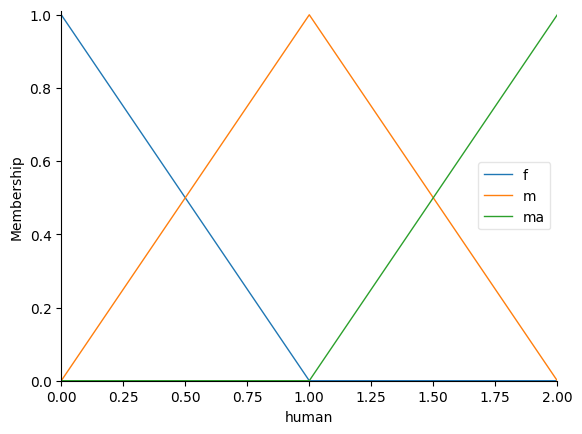

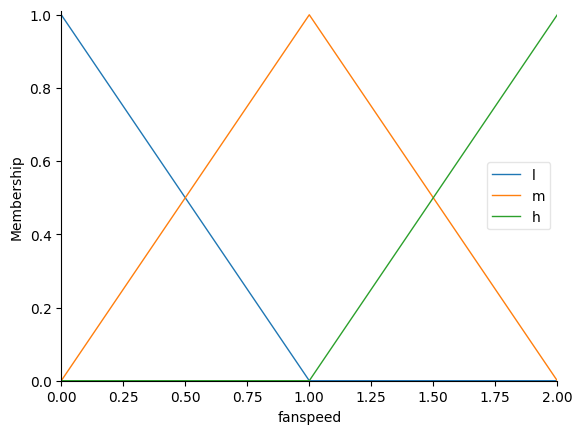

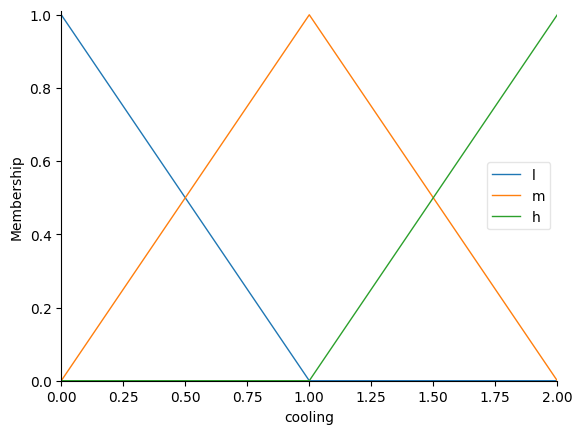

In [16]:
temperature.view()
humidity.view()
human.view()
fanspeed.view()
cooling.view()

In [15]:
#
rule1=ctrl.Rule(temperature['c'],fanspeed['l'])
rule2=ctrl.Rule(temperature['cl'],fanspeed['l'])
rule3=ctrl.Rule(temperature['cm'],fanspeed['m'])
rule4=ctrl.Rule(temperature['w'],fanspeed['m'])
rule5=ctrl.Rule(temperature['h'],fanspeed['h'])
#
rule6=ctrl.Rule(temperature['c'],cooling['l'])
rule7=ctrl.Rule(temperature['cl'],cooling['l'])
rule8=ctrl.Rule(temperature['cm'],cooling['m'])
rule9=ctrl.Rule(temperature['w'],cooling['h'])
rule10=ctrl.Rule(temperature['h'],cooling['h'])
#
rule11=ctrl.Rule(humidity['l'],cooling['l'])
#
rule12=ctrl.Rule(human['f'],cooling['l'])
#
rule13=ctrl.Rule(temperature['h']&humidity['h']&human['ma'], (fanspeed['h'],cooling['h']))
rule14=ctrl.Rule(temperature['cm']&humidity['m']&human['m'], (fanspeed['m'],cooling['m']))
rule15=ctrl.Rule(temperature['cl']&humidity['l']&human['f'], (fanspeed['l'],cooling['l']))

Tốc độ quạt: 1.021705426356589
Độ làm mát: 1.6285714285714286


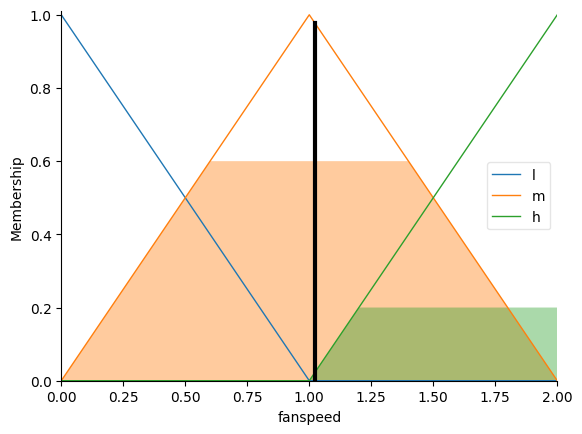

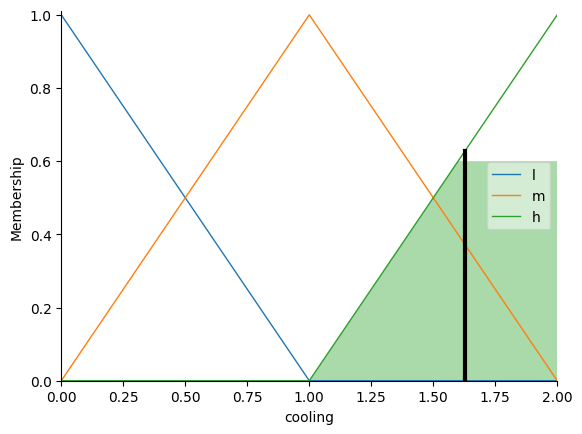

In [19]:

control_system=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10,rule11,rule12,rule13,rule14,rule15])
fuzzy_system=ctrl.ControlSystemSimulation(control_system)
fuzzy_system.input['temperature']=32
fuzzy_system.input['humidity']=52
fuzzy_system.input['human']=1.5
fuzzy_system.compute()
print("Tốc độ quạt:",fuzzy_system.output['fanspeed'])
print("Độ làm mát:",fuzzy_system.output['cooling'])
fanspeed.view(sim=fuzzy_system)
cooling.view(sim=fuzzy_system)
